# Project 1: Baseball
The dataset was obtained from [this site](http://www.seanlahman.com/baseball-archive/statistics).

# Part 1: Managers
Does winning keep a manager employed?
1. Are managers with better records more likely to be back with the same team next season?
2. How much worse were managers who got replaced mid-season?
3. Do longer runs with one team go with better records?

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats

## Load data
Load managers and teams and merge them. Teams gives us `franchID`, so a team that moved or got renamed (e.g. Montreal -> Washington) still counts as the same job.

From readme2014.txt, the Managers table:
```
playerID       Player ID Number
yearID         Year
teamID         Team
lgID           League
inseason       Managerial order.  Zero if the individual managed the team
                 the entire year.  Otherwise denotes where the manager appeared
                 in the managerial order (1 for first manager, 2 for second, etc.)
G              Games managed
W              Wins
L              Losses
rank           Team's final position in standings that year
plyrMgr        Player Manager (denoted by 'Y')
```
Note: in this version of the data, `inseason` is actually **1** (not 0) for a manager who managed the whole year.

In [2]:
managers = pd.read_csv('../dataset/Managers.csv')
managers = managers[['playerID', 'yearID', 'teamID', 'inseason', 'G', 'W', 'L']]
teams = pd.read_csv('../dataset/Teams.csv')
teams = teams[['yearID', 'teamID', 'franchID']]
players = pd.read_csv('../dataset/People.csv')
players = players[['playerID', 'nameFirst', 'nameLast']]

managers = pd.merge(managers, teams, on=['yearID', 'teamID'])
managers.head()

,playerID,yearID,teamID,inseason,G,W,L,franchID
0,wrighha01,1871,BS1,1,31,20,10,BNA
1,woodji01,1871,CH1,1,28,19,9,CNA
2,paborch01,1871,CL1,1,29,10,19,CFC
3,lennobi01,1871,FW1,1,14,5,9,KEK
4,deaneha01,1871,FW1,2,5,2,3,KEK


## NaN
Check for NaN values in the columns we kept.

In [3]:
display(managers[managers.isna().any(axis=1)])

,playerID,yearID,teamID,inseason,G,W,L,franchID


## Modern era only
Keep 1901 onward (the modern AL/NL era). Before that, teams and whole leagues folded constantly, so "not back next year" often just meant the team was gone.

In [4]:
managers = managers[managers.yearID >= 1901]
lastYear = managers.yearID.max()
display(f'{len(managers)} rows, 1901 - {lastYear}')

'2939 rows, 1901 - 2017'

## One row per manager per season
Add up games, wins, and losses for each manager, season, and franchise. Then compute win percentage (`wpct`).

In [5]:
seasons = managers.groupby(['playerID', 'yearID', 'franchID']).agg({'G':'sum', 'W':'sum', 'L':'sum', 'inseason':'max'}).reset_index()
seasons['wpct'] = seasons.W / (seasons.W + seasons.L)
seasons.head()

,playerID,yearID,franchID,G,W,L,inseason,wpct
0,actama99,2007,WSN,162,73,89,1,0.450617
1,actama99,2008,WSN,161,59,102,1,0.366460
2,actama99,2009,WSN,87,26,61,1,0.298851
3,actama99,2010,CLE,162,69,93,1,0.425926
4,actama99,2011,CLE,162,80,82,1,0.493827


### Did the manager finish the season?
The manager who finished the season is the one with the highest `inseason` number for that team that year. Everyone else was replaced mid-season.

In [6]:
lastManager = managers.groupby(['yearID', 'franchID']).agg({'inseason':'max'}).reset_index()
lastManager.columns = ['yearID', 'franchID', 'lastInseason']

seasons = pd.merge(seasons, lastManager, on=['yearID', 'franchID'])
seasons['finished'] = seasons.inseason == seasons.lastInseason
seasons.finished.value_counts()

finished
True     2482
False     433
Name: count, dtype: int64

### Was the manager back with the same team next year?
Shift every season back one year and merge. If a manager has a row for the same franchise in `yearID + 1`, they were back.

Also check that the team itself existed next year (you can't come back to a team that folded, or after the last year of data).

In [7]:
nextYear = seasons[['playerID', 'yearID', 'franchID']].copy()
nextYear['yearID'] = nextYear.yearID - 1
nextYear['backNextYear'] = True
seasons = pd.merge(seasons, nextYear, on=['playerID', 'yearID', 'franchID'], how='left')
seasons['backNextYear'] = seasons.backNextYear.fillna(False).astype(bool)

teamNextYear = teams[['yearID', 'franchID']].drop_duplicates().copy()
teamNextYear['yearID'] = teamNextYear.yearID - 1
teamNextYear['teamNextYear'] = True
seasons = pd.merge(seasons, teamNextYear, on=['yearID', 'franchID'], how='left')
seasons['teamNextYear'] = seasons.teamNextYear.fillna(False).astype(bool)

seasons.head()

,playerID,yearID,franchID,G,W,L,inseason,wpct,lastInseason,finished,backNextYear,teamNextYear
0,actama99,2007,WSN,162,73,89,1,0.450617,1,True,True,True
1,actama99,2008,WSN,161,59,102,1,0.366460,1,True,True,True
2,actama99,2009,WSN,87,26,61,1,0.298851,2,False,False,True
3,actama99,2010,CLE,162,69,93,1,0.425926,1,True,True,True
4,actama99,2011,CLE,162,80,82,1,0.493827,1,True,True,True


## Q1: Are winning managers more likely to be back next year?
Only look at managers who finished the season (the replaced ones are Q2), whose team existed the next year, and who managed at least 20 games (a 3-game interim manager's record is just noise).

In [8]:
finishers = seasons[seasons.finished & seasons.teamNextYear & (seasons.G >= 20)].copy()
back = finishers[finishers.backNextYear]
gone = finishers[~finishers.backNextYear]

display(f'back next year: mean win% = {back.wpct.mean():.3f} (n = {len(back)})')
display(f'not back:       mean win% = {gone.wpct.mean():.3f} (n = {len(gone)})')

# Welch's t-test (equal_var=False) since the two groups are very different sizes
stats.ttest_ind(back.wpct, gone.wpct, equal_var=False)

'back next year: mean win% = 0.512 (n = 1959)'

'not back:       mean win% = 0.461 (n = 436)'

TtestResult(statistic=np.float64(11.42942084877129), pvalue=np.float64(1.3060765389215472e-27), df=np.float64(626.6961415841785))

Text(0.5, 1.0, "Win % of managers who were / weren't back next year")

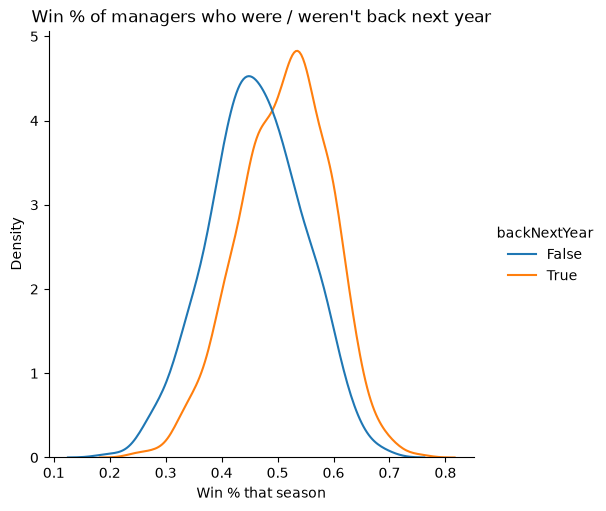

In [9]:
g = sns.displot(data=finishers, x='wpct', hue='backNextYear', kind='kde', common_norm=False)
g.set_axis_labels('Win % that season', 'Density')
plt.title('Win % of managers who were / weren\'t back next year')

### Back-next-year rate by win % bracket

In [10]:
finishers['bracket'] = pd.cut(finishers.wpct, bins=[0, .400, .450, .500, .550, .600, 1.01], right=False,
                              labels=['<.400', '.400-.449', '.450-.499', '.500-.549', '.550-.599', '.600+'])

retention = finishers.groupby('bracket', observed=True).agg({'backNextYear':['mean', 'count']}).reset_index()
retention.columns = ['bracket', 'backRate', 'count']
retention

,bracket,backRate,count
0,<.400,0.630037,273
1,.400-.449,0.725490,357
2,.450-.499,0.802603,461
3,.500-.549,0.868601,586
4,.550-.599,0.887615,436
5,.600+,0.929078,282


Text(0, 0.5, 'Share back next season')

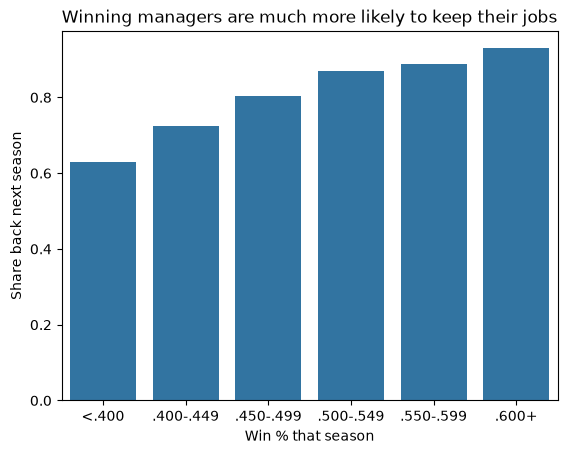

In [11]:
sns.barplot(data=retention, x='bracket', y='backRate')
plt.title('Winning managers are much more likely to keep their jobs')
plt.xlabel('Win % that season')
plt.ylabel('Share back next season')

## Q2: How bad were managers who got replaced mid-season?
Compare managers who were replaced before the season ended to managers who finished it. ("Replaced" includes firings, resignations, and health reasons. The data doesn't say which.)

In [12]:
enough = seasons[seasons.G >= 20].copy()
enough['result'] = enough.finished.map({True: 'Finished season', False: 'Replaced mid-season'})
replaced = enough[enough.result == 'Replaced mid-season']
finished = enough[enough.result == 'Finished season']

display(f'replaced mid-season: mean win% = {replaced.wpct.mean():.3f} (n = {len(replaced)})')
display(f'finished season:     mean win% = {finished.wpct.mean():.3f} (n = {len(finished)})')
stats.ttest_ind(replaced.wpct, finished.wpct, equal_var=False)

'replaced mid-season: mean win% = 0.438 (n = 357)'

'finished season:     mean win% = 0.503 (n = 2430)'

TtestResult(statistic=np.float64(-13.299462050876478), pvalue=np.float64(2.2429529360409115e-34), df=np.float64(459.7149476752123))

Text(0, 0.5, 'Win %')

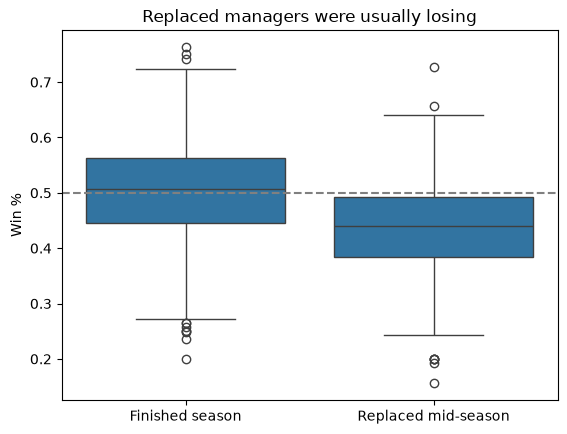

In [13]:
sns.boxplot(data=enough, x='result', y='wpct')
plt.axhline(0.5, linestyle='--', color='gray')
plt.title('Replaced managers were usually losing')
plt.xlabel('')
plt.ylabel('Win %')

## Q3: Do longer runs with one team go with better records?
A **run** = consecutive seasons managing the same franchise. A new run starts whenever the manager, the franchise, or the year (not consecutive) changes.

Runs still going in the last year of data are dropped since we don't know how long they'll last. Runs under 20 total games are dropped too (same reason as Q1).

In [14]:
s = seasons.sort_values(['playerID', 'franchID', 'yearID']).copy()
newRun = (s.playerID != s.playerID.shift()) | (s.franchID != s.franchID.shift()) | (s.yearID != s.yearID.shift() + 1)
s['runID'] = newRun.cumsum()

runs = s.groupby('runID').agg({'playerID':'first', 'franchID':'first', 'yearID':['min', 'max', 'count'], 'G':'sum', 'W':'sum', 'L':'sum'}).reset_index()
runs.columns = ['runID', 'playerID', 'franchID', 'start', 'end', 'seasons', 'G', 'W', 'L']
runs['wpct'] = runs.W / (runs.W + runs.L)
runs = runs[(runs.end < lastYear) & (runs.G >= 20)].copy()
runs.head()

,runID,playerID,franchID,start,end,seasons,G,W,L,wpct
0,1,actama99,CLE,2010,2012,3,480,214,266,0.445833
1,2,actama99,WSN,2007,2009,3,410,158,252,0.385366
3,4,adcocjo01,CLE,1967,1967,1,162,75,87,0.462963
5,6,aloufe01,SFG,2003,2006,4,646,342,304,0.529412
6,7,aloufe01,WSN,1992,2001,10,1408,691,717,0.490767


SignificanceResult(statistic=np.float64(0.391355200096945), pvalue=np.float64(1.4366601360527937e-30))

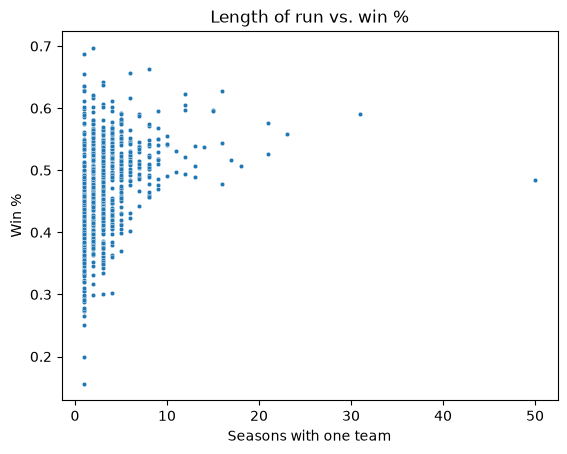

In [15]:
sns.scatterplot(data=runs, x='seasons', y='wpct', s=10)
plt.title('Length of run vs. win %')
plt.xlabel('Seasons with one team')
plt.ylabel('Win %')

# Spearman since run length is very skewed (most runs are 1-3 seasons)
stats.spearmanr(runs.seasons, runs.wpct)

,length,meanWpct,count
0,1,0.432706,211
1,2-3,0.471154,341
2,4-6,0.499782,167
3,7+,0.527635,78


Text(0, 0.5, 'Mean win %')

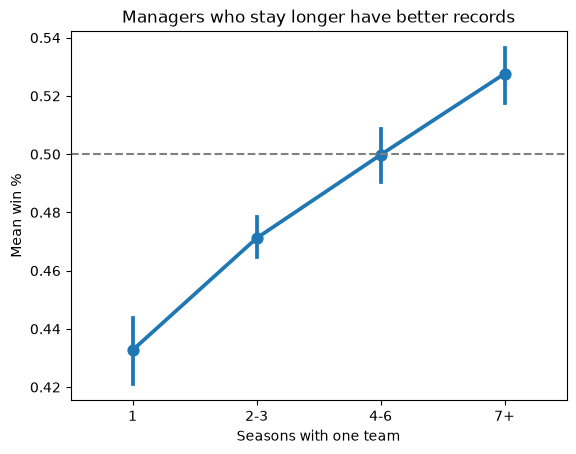

In [16]:
runs['length'] = pd.cut(runs.seasons, bins=[0, 1, 3, 6, 100], labels=['1', '2-3', '4-6', '7+'])

byLength = runs.groupby('length', observed=True).agg({'wpct':['mean', 'count']}).reset_index()
byLength.columns = ['length', 'meanWpct', 'count']
display(byLength)

sns.pointplot(data=runs, x='length', y='wpct')
plt.axhline(0.5, linestyle='--', color='gray')
plt.title('Managers who stay longer have better records')
plt.xlabel('Seasons with one team')
plt.ylabel('Mean win %')

### Longest runs with one team

In [17]:
longest = pd.merge(runs, players, on='playerID')
longest = longest.sort_values('seasons', ascending=False).head(10)
longest[['nameFirst', 'nameLast', 'franchID', 'start', 'end', 'seasons', 'wpct']]

,nameFirst,nameLast,franchID,start,end,seasons,wpct
434,Connie,Mack,OAK,1901,1950,50,0.484316
485,John,McGraw,SFG,1902,1932,31,0.590670
5,Walter,Alston,LAD,1954,1976,23,0.558445
394,Tom,Lasorda,LAD,1976,1996,21,0.526333
116,Bobby,Cox,ATL,1990,2010,21,0.576017
621,Wilbert,Robinson,LAD,1914,1931,18,0.506259
10,Sparky,Anderson,DET,1979,1995,17,0.516092
478,Joe,McCarthy,NYY,1931,1946,16,0.627417
393,Tony,LaRussa,STL,1996,2011,16,0.543629
360,Tom,Kelly,MIN,1986,2001,16,0.478188


## Takeaways (so far)
- **Winning keeps you employed.** The back-next-year rate climbs steadily with win %: about 6 in 10 managers under .400 came back, vs. about 9 in 10 above .600.
- **Mid-season replacements were almost always losing**, well below .500 on average, compared to about .500 for managers who finished the year.
- **Longer runs go with better records**, but this cuts both ways: good managers get to stay, *and* staying means you survived the bad years. This is a correlation, not proof that longevity causes winning.
- **Fun outlier for the presentation:** Connie Mack managed the Philadelphia A's for 50 straight years with a *losing* record. He also owned the team.

**Caveats:** "not back" doesn't distinguish firing from retiring or quitting, and win % is only one thing owners judge (playoffs, expectations, payroll).